imports

In [36]:
import torch
import random
import matplotlib.pyplot as plt
import torchvision
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import os
import cv2
import numpy as np

output folder

In [37]:
if not os.path.exists('./OpenCV_Denoised'):
    os.mkdir('./OpenCV_Denoised')

print("Setup done")

Setup done


Helper Function

In [38]:
def to_img(x):
    x = 0.5 * (x + 1)
    x = x.clamp(0, 1)
    return x

Convert tensor -> OpenCV

In [39]:
def tensor_to_cv(img_tensor):

    # remove channel dimension
    img = img_tensor.squeeze().cpu().detach().numpy()

    # [-1,1] -> [0,1]
    img = (img + 1) / 2.0

    # [0,1] -> [0,255]
    img = (img * 255).astype(np.uint8)

    return img

Hyperparameters

In [40]:
batch_size = 1   # IMPORTANT: process one image at a time

Data set

In [41]:
img_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

loading testing data

In [42]:
xray_test_dataset = datasets.ImageFolder(
    './chest_xray/test',
    transform=img_transform
)

print("Test samples:", len(xray_test_dataset))

test_dataloader = DataLoader(
    xray_test_dataset,
    batch_size=batch_size,
    shuffle=False
)

Test samples: 624


Gaussian Noise

In [43]:
def add_noise(img, sigma=0.2):

    noise = torch.randn_like(img) * sigma

    noisy_img = img + noise

    noisy_img = torch.clamp(noisy_img, -1., 1.)

    return noisy_img

Open CV

In [44]:
def opencv_denoise(img_tensor, h_value ):

    img = tensor_to_cv(img_tensor)

    denoised = cv2.fastNlMeansDenoising(
        img,
        None,
        h=h_value,
        templateWindowSize=7,
        searchWindowSize=21
    )

    return denoised

Save comparison image (Original | Noisy | Denoised)

In [45]:
def save_comparison(clean_img, noisy_img, denoised_img, idx):

    clean_np = tensor_to_cv(clean_img)
    noisy_np = tensor_to_cv(noisy_img)

    combined = np.hstack([
        clean_np,
        noisy_np,
        denoised_img
    ])

    save_path = f'./OpenCV_Denoised/sample_{idx}.png'

    cv2.imwrite(save_path, combined)

Processing loop

In [46]:
# Noise levels to test
noise_levels = [0.1, 0.2, 0.3]

# Base output folder
base_output_folder = './OpenCV_Denoised'

if not os.path.exists(base_output_folder):
    os.mkdir(base_output_folder)

for sigma in noise_levels:
    print(f"\n=== Processing all images with sigma = {sigma} ===")

    # Create a folder for this noise level
    output_folder = os.path.join(base_output_folder, f"sigma_{int(sigma*100)}")
    if not os.path.exists(output_folder):
        os.mkdir(output_folder)

    mse_list = []

    for idx, data in enumerate(test_dataloader):
        img, label = data

        # Add noise (fixed sigma for this run)
        noisy_img = add_noise(img, sigma=sigma)

        # OpenCV denoising
        h_value = int(sigma * 100)
        denoised_img = opencv_denoise(noisy_img, h_value)

        # Save comparison image
        clean_np = tensor_to_cv(img)
        noisy_np = tensor_to_cv(noisy_img)
        combined = np.hstack([clean_np, noisy_np, denoised_img])
        save_path = os.path.join(output_folder, f'sample_{idx}.png')
        cv2.imwrite(save_path, combined)

        # Compute MSE
        original = clean_np.astype(np.float32) / 255.0
        denoised_norm = denoised_img.astype(np.float32) / 255.0
        mse = np.mean((original - denoised_norm) ** 2)
        mse_list.append(mse)

        # Progress print
        if idx % 50 == 0:
            print(f"Processed {idx}/{len(test_dataloader)} images")

    # Average MSE for this noise level
    avg_mse = np.mean(mse_list)
    print(f"Average MSE for sigma={sigma}: {avg_mse:.6f}")


=== Processing all images with sigma = 0.1 ===
Processed 0/624 images
Processed 50/624 images
Processed 100/624 images
Processed 150/624 images
Processed 200/624 images
Processed 250/624 images
Processed 300/624 images
Processed 350/624 images
Processed 400/624 images
Processed 450/624 images
Processed 500/624 images
Processed 550/624 images
Processed 600/624 images
Average MSE for sigma=0.1: 0.000882

=== Processing all images with sigma = 0.2 ===
Processed 0/624 images
Processed 50/624 images
Processed 100/624 images
Processed 150/624 images
Processed 200/624 images
Processed 250/624 images
Processed 300/624 images
Processed 350/624 images
Processed 400/624 images
Processed 450/624 images
Processed 500/624 images
Processed 550/624 images
Processed 600/624 images
Average MSE for sigma=0.2: 0.001560

=== Processing all images with sigma = 0.3 ===
Processed 0/624 images
Processed 50/624 images
Processed 100/624 images
Processed 150/624 images
Processed 200/624 images
Processed 250/624 

Visualize

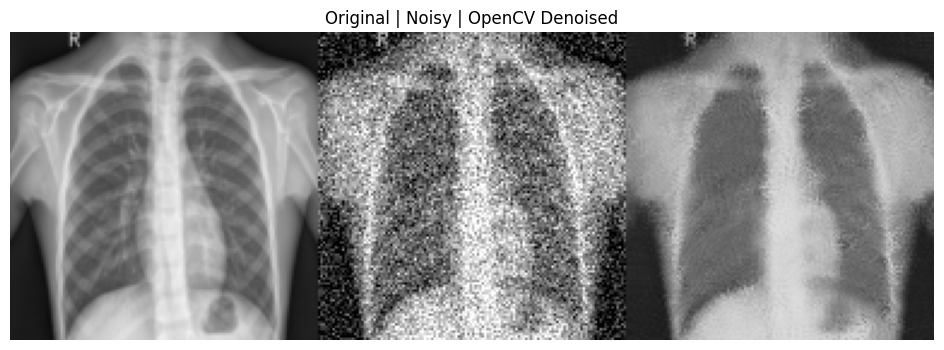

In [47]:
example_path = "./OpenCV_Denoised/sample_0.png"

example_img = cv2.imread(example_path)

plt.figure(figsize=(12,4))

plt.imshow(example_img, cmap='gray')

plt.title("Original | Noisy | OpenCV Denoised")

plt.axis('off')

plt.show()

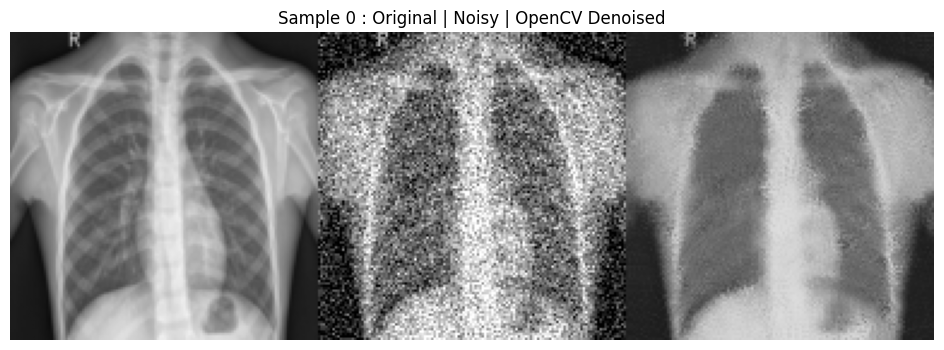

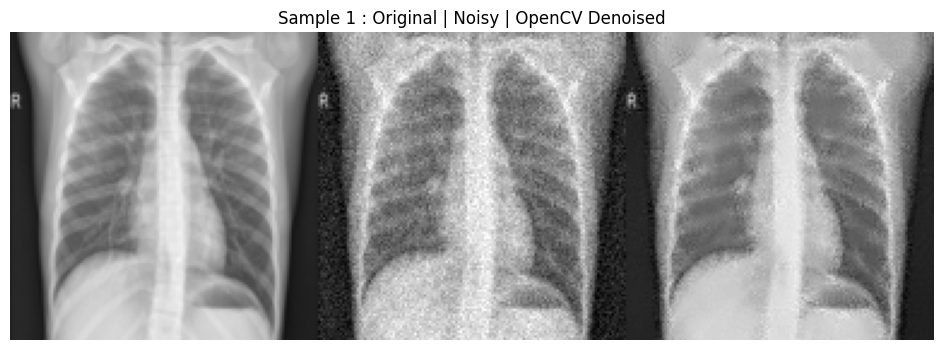

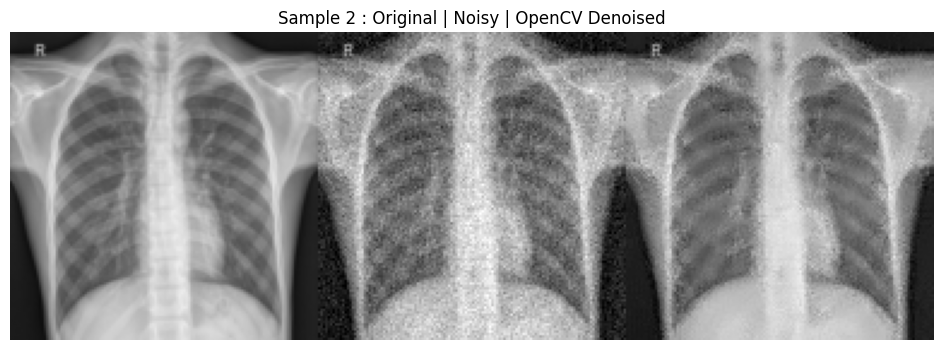

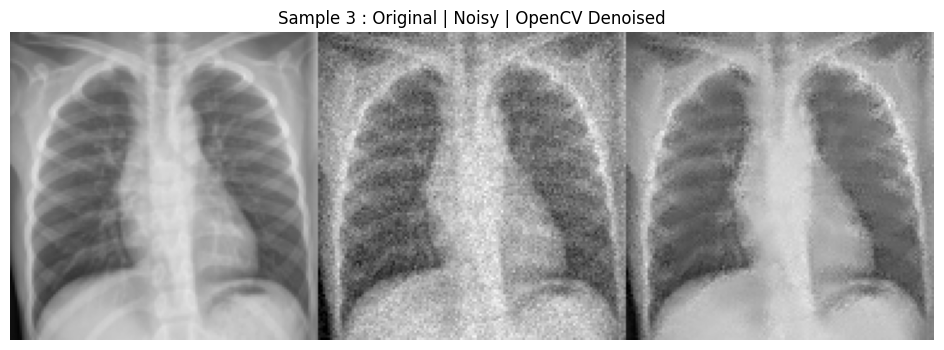

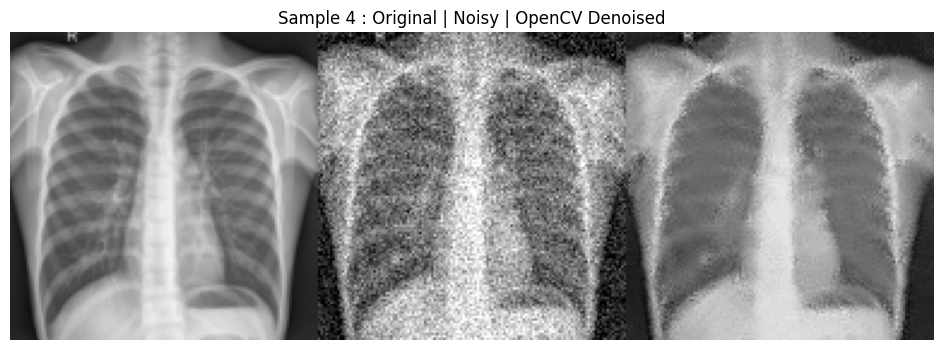

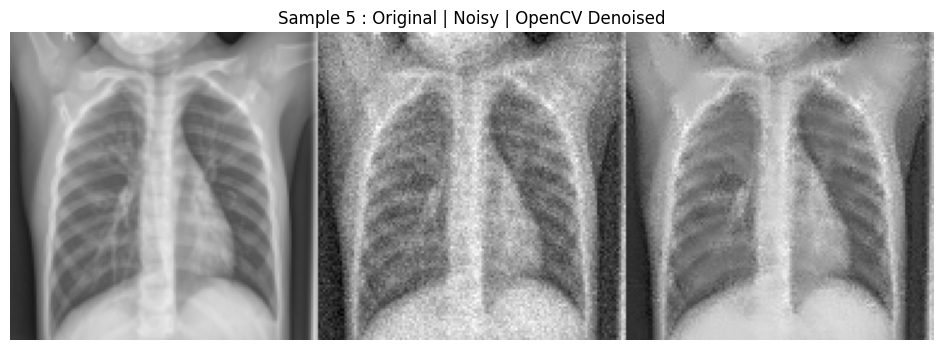

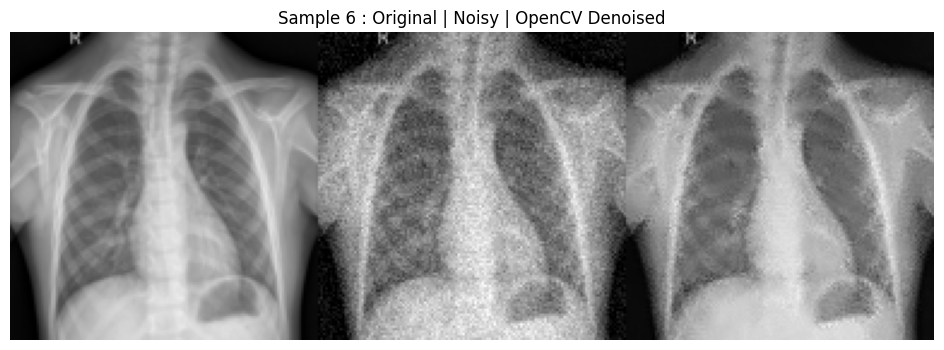

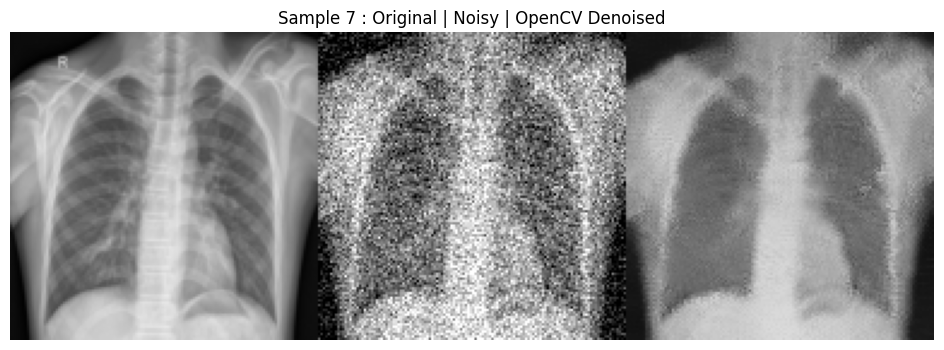

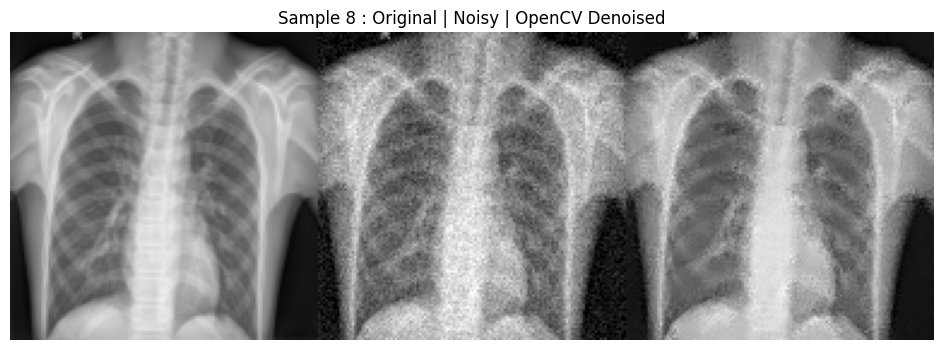

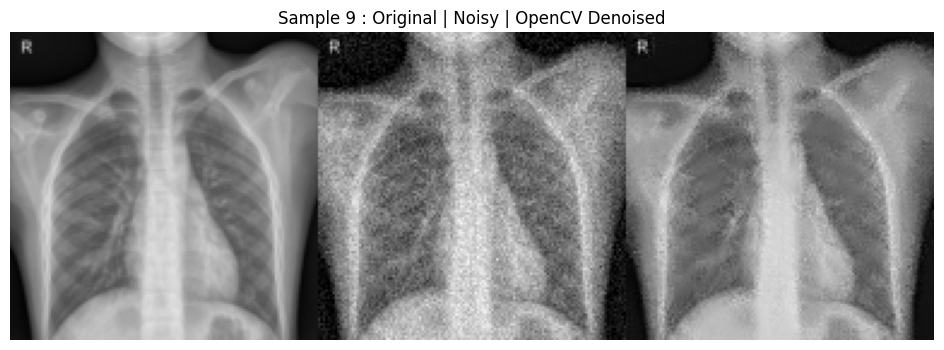

In [ ]:
for i in range(10):

    img_path = f"./OpenCV_Denoised/sample_{i}.png"

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(12,4))

    plt.imshow(img, cmap='gray')

    plt.title(f"Sample {i} : Original | Noisy | OpenCV Denoised")

    plt.axis('off')

    plt.show()